In [1]:
import os 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import csv, random
import time
from pathlib import Path
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype = np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = str(Path(os.environ.get("SAM2_CHECKPOINT", "../checkpoints/sam2.1_hiera_large.pt")))
model_cfg = str(Path("configs/sam2.1/sam2.1_hiera_l.yaml"))

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

In [5]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=96,
    points_per_batch=128,
    pred_iou_thresh=0.5,
    stability_score_thresh=0.92,
    stability_score_offset=0.6,
    crop_n_layers=1,
    box_nms_thresh=0.8,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50.0,
    use_m2m=True,
)

In [6]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

In [16]:
paired_csv = Path.home() / "skimage_segmentation" / "paired.csv"

with paired_csv.open(newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

def water_fraction_from_npz(npz_path):
    d = np.load(npz_path)
    m = d["ice_mask"].astype(bool)
    return float(m.mean())
    
good_idxs = []
for idx in range(len(rows)):
    npz_path = rows[idx]["npz_path"].strip()
    try:
        f = water_fraction_from_npz(npz_path)
    except Exception:
        continue
    if 0.05 < f < 0.95:
        good_idxs.append(idx)

idxs = good_idxs if len(good_idxs) > 0 else list(range(len(rows)))
print("good idxs:", idxs[:30])


good idxs: [0, 10, 11, 18, 20, 21, 27, 30, 38, 39, 48, 56, 65, 73, 74, 82, 83, 91, 99, 100, 109, 118, 119, 128, 129]


In [17]:
test_idxs = [10, 48, 119]
result = []

for idx in test_idxs:
    png_path = rows[idx]["png_path"].strip()
    npz_path = rows[idx]["npz_path"].strip()
    
    image = load_png_as_rgb(png_path)
    
    data = np.load(npz_path)
    ice_mask = data["ice_mask"]           
    
    t0 = time.perf_counter()
    masks = mask_generator_2.generate(image)
    t_generate = time.perf_counter() - t0

    result.append({
        'idx': idx,
        'image': image,
        'masks': masks,
        'ice_mask': ice_mask           
     
    })
    
    print("masks:", len(masks))
    print("keys:", masks[0].keys())
    print("ice_mask unique:", np.unique(ice_mask))
    print("ice pixels:", (~ice_mask).sum())
    print("water pixels:", ice_mask.sum())
    print("generate time:", t_generate)

/home/predm/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/home/predm/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


masks: 45
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 100268
water pixels: 161876
generate time: 116.27240112800064
masks: 25
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 160267
water pixels: 101877
generate time: 278.00548387099843
masks: 118
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 204759
water pixels: 57385
generate time: 87.13701791700078


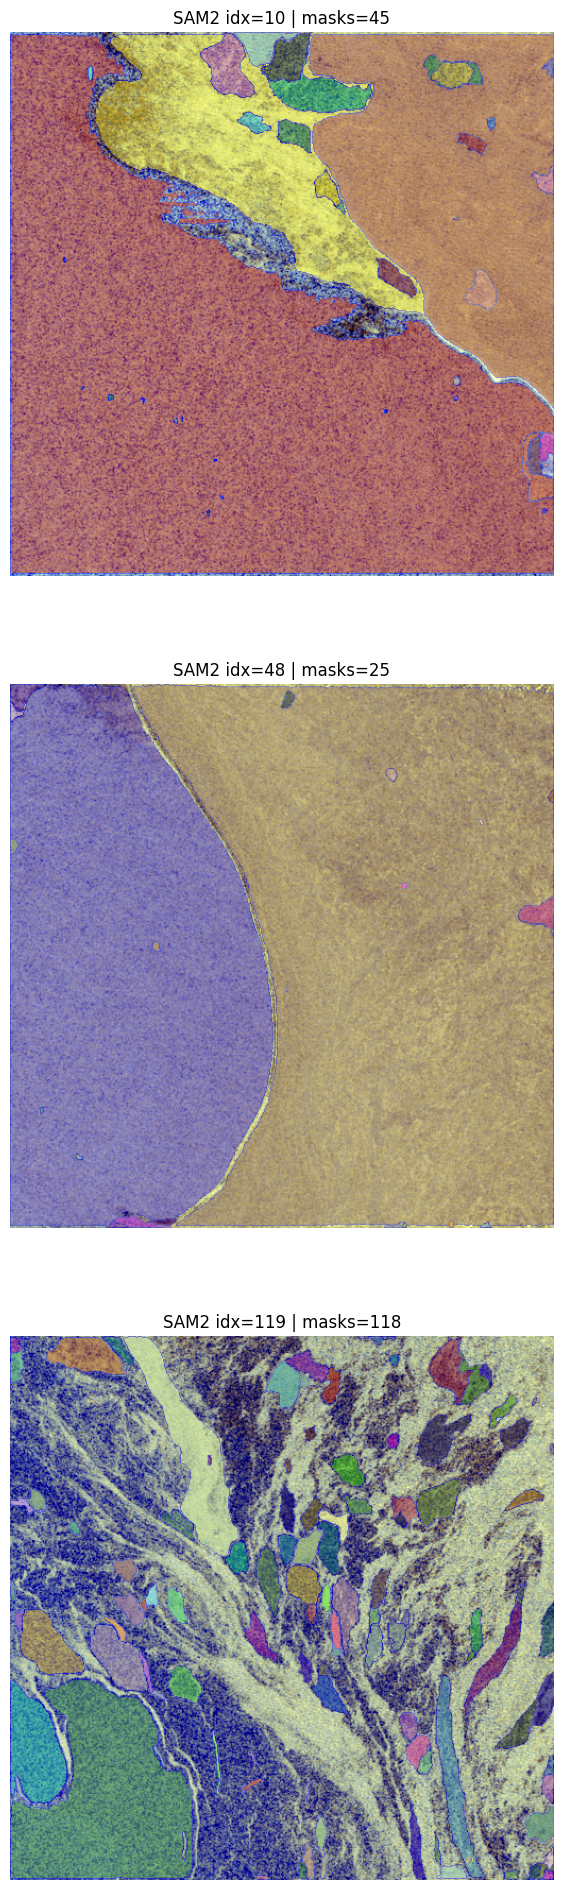

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(8, 24))

for row, item in enumerate(result):
    image = item["image"]
    masks = item["masks"]
    idx = item["idx"]

    axes[row].imshow(image)
    plt.sca(axes[row])
    show_anns(masks)

    axes[row].set_title(f"SAM2 idx={idx} | masks={len(masks)}")
    axes[row].axis("off")

plt.show()

In [19]:
results = []
for row, item in enumerate(result):
    idx = item["idx"]
    image = item["image"]
    masks = item["masks"]
    ice_mask = item["ice_mask"]
    
    H, W = ice_mask.shape
    sam2_pred = np.full((H, W), -1, dtype = np.int8)
    masks_sorted = sorted(masks, key=lambda x: x["area"], reverse=True)

    water_mask = ice_mask.astype(bool)
    
    for ann in masks_sorted:
        m = ann["segmentation"]
        if m.sum() == 0:
            continue
            
        water_fraction = water_mask[m].mean()
        sam2_pred[m] = 1 if water_fraction > 0.5 else 0
    
    valid = (sam2_pred != -1)
    errors = (sam2_pred != ice_mask.astype(np.int8)) & valid
    unseg = (sam2_pred == -1)
    
    pred_water = (sam2_pred == 1).sum()
    pred_ice   = (sam2_pred == 0).sum()
    unk   = (sam2_pred == -1).sum()
    
    results.append({
        'idx': idx,
        'image': image,
        'masks': masks,
        'ice_mask': ice_mask,
        'sam2_pred': sam2_pred,
        'pred_water': pred_water,
        'pred_ice': pred_ice,
        'unk': unk,
        'errors': errors,
        'unseg': unseg
        })
    
df = pd.DataFrame(results)
df['masks'] = df['masks'].apply(len)
df = df[["idx", "masks", "pred_water", "pred_ice", "unk"]]
df

,idx,masks,pred_water,pred_ice,unk
0,10,45,156877,94304,10963
1,48,25,103331,154330,4483
2,119,118,35804,42720,183620


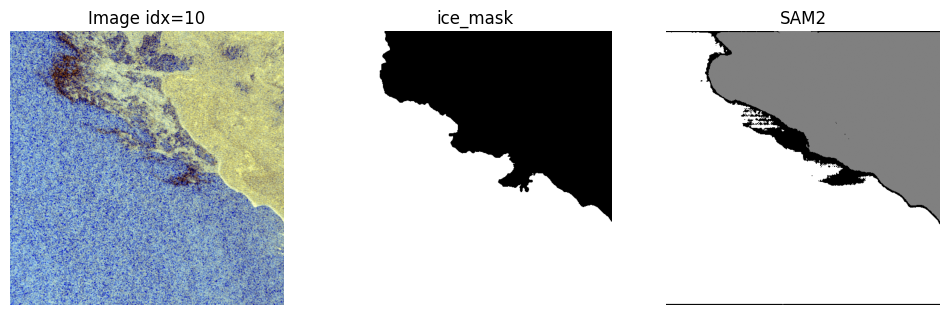

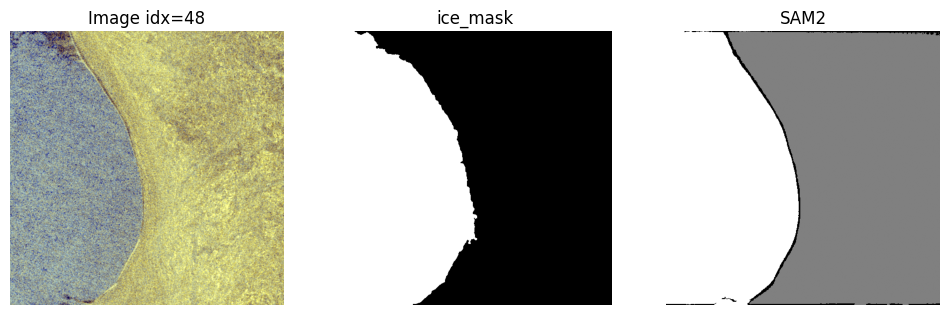

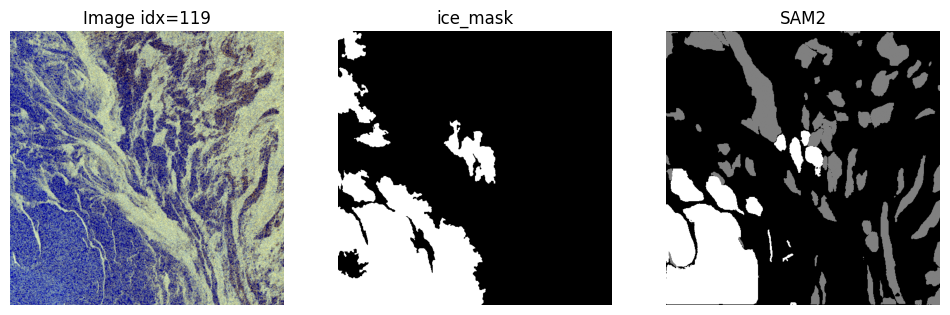

In [20]:
for item in results:

    image = item["image"]
    ice_mask = item["ice_mask"]
    sam2_pred = item["sam2_pred"]
    idx = item["idx"]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title(f"Image idx={idx}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(ice_mask, cmap="gray")
    plt.title("ice_mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(sam2_pred, cmap="gray", vmin=-1, vmax=1)
    plt.title("SAM2")
    plt.axis("off")

    plt.show()

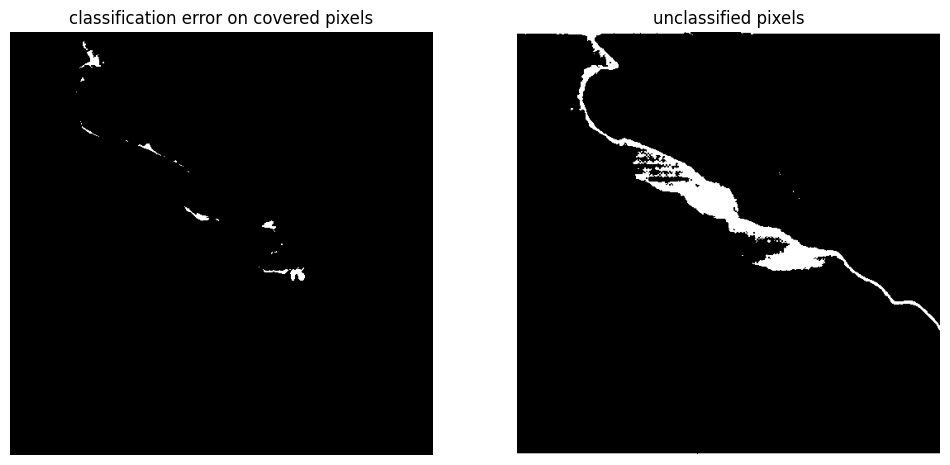

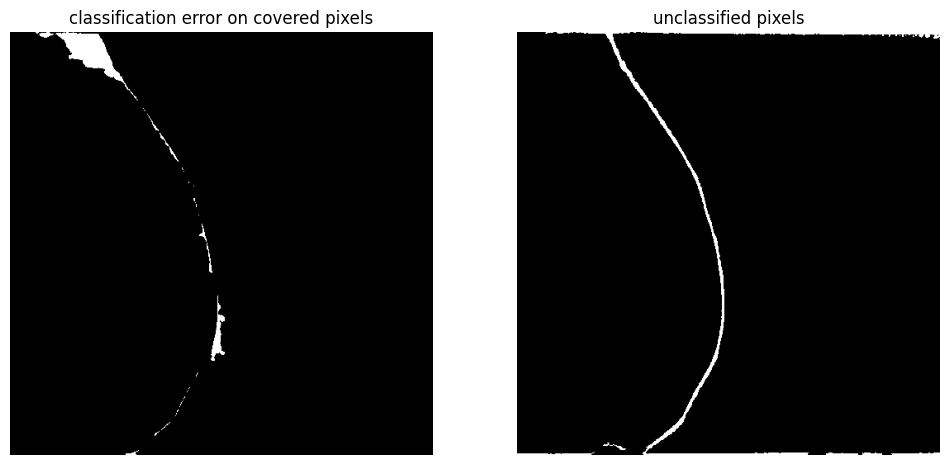

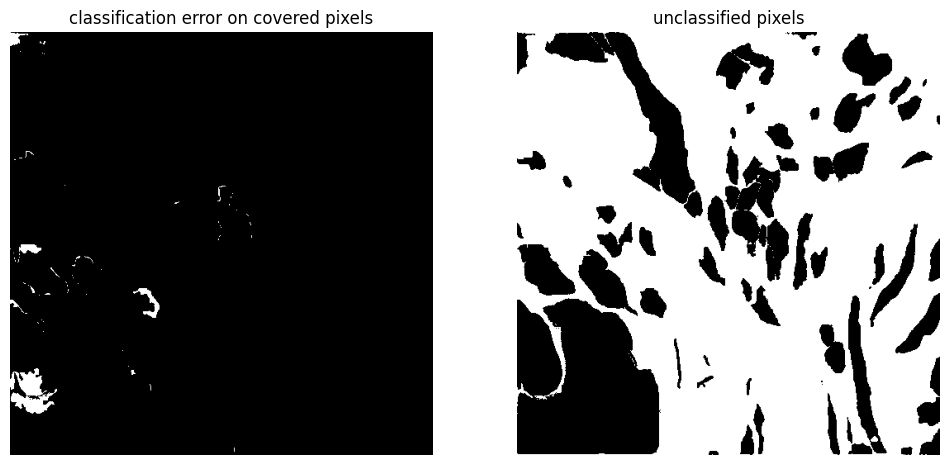

In [21]:
for item in results:
    errors = item['errors']
    unseg = item['unseg']

    plt.figure(figsize=(12,8))

    plt.subplot(1,2,1)
    plt.imshow(errors, cmap="gray")
    plt.title("classification error on covered pixels")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(unseg, cmap="gray")
    plt.title("unclassified pixels")
    plt.axis("off")

    plt.show()